In [123]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from atmosphere_model.main import plot, run

# Molar masses (g/mol) of relevant gas species
mu_dict = {'SiO2': 60.08,
            'TiO2': 79.87,
            'Al2O3': 101.96,
            'FeO_star': 71.84,
            'FeO': 71.84,
            'Fe2O3': 159.69,
            'MnO': 70.94,
            'MgO': 40.30,
            'CaO': 56.08,
            'Na2O': 61.98,
            'K2O': 94.20,
            'P2O5': 141.94,
            'S': 32.06,
            'C': 12.01,
            'H': 1.008,
            'O': 16.00,
            'H2O': 18.01528,
            'H2': 2.01588,
            'H2S': 34.08088,
            'CO2': 44.0095,
            'CO': 28.0101,
            'CH4': 16.04246,
            'SO2': 64.066,
            'S2': 64.142
           }

In [124]:
def calc_FeOratio(T, P, fO2, x_dict, T0 = 1673.0):
    # INPUT P IN BARS
    # Convert it to Pa now
    P = P * 1e5 # Pa

    # Table 7 parameters
    a  = 0.196
    b  = 1.1492e4   # K
    c  = -6.675
    d_Al2O3 = -2.243
    d_FeO_star   =  -1.828
    d_CaO   =  3.201
    d_Na2O  =  5.854
    d_K2O   =  6.215
    e  = -3.36
    f  = -7.01e-7      # K Pa^-1
    g  = -1.54e-10     # Pa^-1
    h  =  3.85e-17     # K Pa^-2

    # Composition term without FeO: Σ d_i X_i  (i ≠ FeO)
    comp = (
        d_Al2O3 * x_dict.get("Al2O3", 0.0) +
        d_FeO_star * x_dict.get("FeO_star", 0.0) +
        d_CaO   * x_dict.get("CaO",   0.0) +
        d_Na2O  * x_dict.get("Na2O",  0.0) +
        d_K2O   * x_dict.get("K2O",   0.0)
    )

    # P–T terms
    bracket = 1.0 - (T0 / T) - np.log(T / T0)
    PT_term = (f * (P / T)) + (g * ((T - T0) / T) * P) + (h * (P**2 / T))

    # Full equation
    ratio_Fe2O3_to_FeO = np.exp((a*np.log(fO2)) + (b/T) + c + comp + (e*bracket) + PT_term)

    return ratio_Fe2O3_to_FeO

def calc_CO2_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_co3 = 60.01 # Molar mass of CO3 in g/mol

    C_CO2 = 0.14
    B_CO2 = -5.3
    b_CO2 = 15.8
    d_Al2O3 = 3.8
    d_FeO = -16.3
    d_Na2O = 20.1

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])
    
    extra_term = (d_Al2O3 * x_dict.get("Al2O3", 0.0)/(x_dict["CaO"] + x_dict["K2O"] + x_dict["Na2O"])) + \
                 (d_FeO * (x_FeO + x_dict["MgO"])) +  (d_Na2O * (x_dict["Na2O"] + x_dict["K2O"]))

    S1 = np.log(mu_magma/(mu_co3*1e6)) + (C_CO2*P/T) + B_CO2 + (b_CO2*NBO_O) + extra_term # CO2

    return S1


def calc_H2O_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_h2o = 18.01528 # Molar mass of H2O in g

    a_H2O = 0.54
    b_H2O = 1.24
    B_H2O = -2.95
    C_H2O = 0.02

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])

    S2 = np.log(mu_magma/(mu_h2o*100)) + (C_H2O*P/T) + B_H2O + (b_H2O*NBO_O) # H2O

    return S2

def calc_sulfate_ratio(Fe2O3_FeO_ratio, T):
    # SULFATE CHANGE: estimate melt sulfate/sulfide using a Nash-2019-style redox relation.
    fe3_fe2 = max(2.0 * Fe2O3_FeO_ratio, np.finfo(float).tiny)
    return 10 ** (8*np.log10(fe3_fe2) + (8.7436e6 / T**2) - (27703 / T) + 20.273)

In [125]:
def calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False):

    ### Initialize the magma composition

    mass_frac_dict = {
           'SiO2': 47.95 * 1e-2, # wt% * 1e-2
           'TiO2': 1.67 * 1e-2, # wt% * 1e-2
           'Al2O3': 17.32 * 1e-2, # wt% * 1e-2
           'MnO': 0 * 1e-2, # wt% * 1e-2
           'MgO': 5.76 * 1e-2, # wt% * 1e-2
           'CaO': 10.93 * 1e-2, # wt% * 1e-2
           'Na2O': 3.45 * 1e-2, # wt% * 1e-2
           'K2O': 1.99 * 1e-2, # wt% * 1e-2
           'P2O5': 0.51 * 1e-2, # wt% * 1e-2
           'H2O': mH2O_sat, # ppm * 1e-6
            'CO2': mCO2_sat, # ppm * 1e-6
            'S': mS_sat, # ppm * 1e-6
            'FeO_star': FeO_star_wt, # wt% * 1e-2
            'FeO': 0.0, # Placeholder, will be calculated later
            'Fe2O3': 0.0 # Placeholder, will be calculated later
           }

    mu_magma = 1/sum([mass_frac_dict[oxide]/mu_dict[oxide] for oxide in mass_frac_dict.keys()])
    if verbose:
        print("Magma molar mass: ", mu_magma)

    mole_frac_dict = {
        'SiO2':     mass_frac_dict['SiO2']     * mu_magma / mu_dict['SiO2'],
        'TiO2':     mass_frac_dict['TiO2']     * mu_magma / mu_dict['TiO2'],
        'Al2O3':    mass_frac_dict['Al2O3']    * mu_magma / mu_dict['Al2O3'],
        'FeO_star': mass_frac_dict['FeO_star'] * mu_magma / mu_dict['FeO'],
        'FeO':      mass_frac_dict['FeO']      * mu_magma / mu_dict['FeO'],
        'Fe2O3':    mass_frac_dict['Fe2O3']    * mu_magma / mu_dict['Fe2O3'],
        'MnO':      mass_frac_dict['MnO']      * mu_magma / mu_dict['MnO'],
        'MgO':      mass_frac_dict['MgO']      * mu_magma / mu_dict['MgO'],
        'CaO':      mass_frac_dict['CaO']      * mu_magma / mu_dict['CaO'],
        'Na2O':     mass_frac_dict['Na2O']     * mu_magma / mu_dict['Na2O'],
        'K2O':      mass_frac_dict['K2O']      * mu_magma / mu_dict['K2O'],
        'P2O5':     mass_frac_dict['P2O5']     * mu_magma / mu_dict['P2O5'],
        'H2O':      mass_frac_dict['H2O']      * mu_magma / mu_dict['H2O'],
        'CO2':      mass_frac_dict['CO2']      * mu_magma / mu_dict['CO2'],
        'S':        mass_frac_dict['S']        * mu_magma / mu_dict['S'],
    }

    xO_oxides = mole_frac_dict['SiO2']*2 + mole_frac_dict['TiO2']*2 + mole_frac_dict['Al2O3']*3 + \
                mole_frac_dict['MnO'] + mole_frac_dict['MgO'] + mole_frac_dict['CaO'] + \
                mole_frac_dict['Na2O'] + mole_frac_dict['K2O'] + mole_frac_dict['P2O5']*5

    ### Get mole fractions
    xH2O_sat = mole_frac_dict['H2O']
    xCO2_sat = mole_frac_dict['CO2']
    xS_sat   = mole_frac_dict['S']

    ### Equilibrium constants for speciation reactions
    K1 = np.exp(-29755.11319228574/T+6.652127716162998) # H2 + 0.5O2 = H2O
    K2 = np.exp(-33979.12369002451/T+10.418882755464773) # CO + 0.5O2 = CO2
    K3 = np.exp(-96444.47151911151/T+0.22260815074146403) # CH4 + 2O2 = CO2 + 2H2O
    K4 = np.exp(4.35250424e+04/T-8.80403494e+00) # 0.5S2 + O2 = SO2
    K5 = np.exp(1.90560415e+04/T-8.60366131e-01) # H2S + 0.5O2 = 0.5S2 + H2O

    def nan_results():
        nan_arr = np.full_like(np.logspace(3, -5, num=9), np.nan, dtype=float)
        return {
            'P': nan_arr.copy(),
            'H2O': nan_arr.copy(),
            'H2': nan_arr.copy(),
            'CO2': nan_arr.copy(),
            'CO': nan_arr.copy(),
            'CH4': nan_arr.copy(),
            'S2': nan_arr.copy(),
            'SO2': nan_arr.copy(),
            'H2S': nan_arr.copy(),
            'O2': nan_arr.copy(),
            'xCO2': nan_arr.copy(),
            'xH2O': nan_arr.copy(),
            'xH2': nan_arr.copy(),
            'xS2': nan_arr.copy(),
            'xS6': nan_arr.copy(),
            'xS': nan_arr.copy(),
            'alphaG': nan_arr.copy(),
            'FMQ': nan_arr.copy(),
            'xCO2_sat': np.nan,
            'xH2O_sat': np.nan,
            'xH2_sat': np.nan,
            'xS2_sat': np.nan,
            'xS6_sat': np.nan,
            'xS_sat': np.nan,
            'mu_magma': np.nan
        }

    ### Calculate gas-melt composition at saturation

    P_sat = 1000 # bar, The while loop is to converge on P_sat
    max_sat_iter = 200
    for sat_iter in range(max_sat_iter):
        ### Calculate actual fO2 at saturation
        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ_sat = (-A_fug/T+B_fug+C_fug*(P_sat-1)/T)
        fO2_sat = 10**(log_FMQ_sat+FMQ_sat)

        ### Calculate FeO and Fe2O3 mole fractions at saturation
        Fe2O3_FeO_ratio = calc_FeOratio(T, P_sat, fO2_sat, mole_frac_dict)
        x_FeO_sat = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
        x_Fe2O3_sat = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)

        ### Calculate sulfur solubility at saturation
        m_FeO_pct = 100 * x_FeO_sat * mu_dict['FeO'] / mu_magma # Convert mole fraction to wt%
        Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct)
        sulfate_ratio_sat = calc_sulfate_ratio(Fe2O3_FeO_ratio, T)
        xS2_sat = xS_sat / (1 + sulfate_ratio_sat)
        xS6_sat = xS_sat - xS2_sat

        d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
        P_CO2_sat = np.exp((np.log(xCO2_sat) - (xH2O_sat * d_H2O) - calc_CO2_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_CO2)
        P_H2O_sat = np.exp((np.log(xH2O_sat) - calc_H2O_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_H2O) ## From Wogan 2020
        P_S2_sat  = (fO2_sat*xS2_sat**2)/(Cs**2)

        ### Gas composition at saturation
        P_H2_sat = K1*P_H2O_sat/((fO2_sat)**0.5)
        P_CO_sat = K2*P_CO2_sat/((fO2_sat)**0.5)
        P_CH4_sat = K3*P_CO2_sat*(P_H2O_sat**2)/(fO2_sat**2)
        P_SO2_sat = K4*fO2_sat*(P_S2_sat**0.5)
        P_H2S_sat = (P_S2_sat**0.5)*P_H2O_sat/(K5*(fO2_sat**0.5))
        # xH2_sat = np.exp(1.28*np.log(P_H2_sat) + np.log(mu_magma*3.4e-7/(2.016*2.7)))


        P_calc = P_CO2_sat + P_H2O_sat + P_S2_sat + P_H2_sat + P_H2S_sat + P_SO2_sat + P_CO_sat + P_CH4_sat
        if not np.isfinite(P_calc) or P_calc <= 0:
            print(f"Warning: Encountered non-physical saturation pressure ({P_calc}). Returning NaNs.")
            return nan_results()
        if abs(P_calc - P_sat) < 1:
            P_sat = P_calc
            break
        P_sat = P_calc
    else:
        if verbose:
            print(f"Warning: Saturation pressure did not converge after {max_sat_iter} iterations. Returning NaNs.")
        return nan_results()

    ### Calculate total elemental abundances at saturation    
    xC_tot = (((P_CO2_sat + P_CO_sat + P_CH4_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(xCO2_sat)) # total C
    xH_tot = (((2*P_H2O_sat + 4*P_CH4_sat + 2*P_H2S_sat + 2*P_H2_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(2*xH2O_sat)) # total H
    xS_tot = ((2*P_S2_sat + P_SO2_sat + P_H2S_sat)/P_sat)*alphaG_sat + ((1 - alphaG_sat)*(xS2_sat + xS6_sat)) # total S
    xO_tot = (((P_H2O_sat + 2*P_SO2_sat + 2*P_CO2_sat + P_CO_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(1*xH2O_sat + 2*xCO2_sat + 1*x_FeO_sat + 3*x_Fe2O3_sat + 0*xS6_sat + 0*mole_frac_dict["FeO_star"])) # total O

    P_grid = np.logspace(3, -6, num=46) # bar

    P_H2O_arr = np.full_like(P_grid, np.nan, dtype=float); P_H2_arr = np.full_like(P_grid, np.nan, dtype=float); P_CO2_arr = np.full_like(P_grid, np.nan, dtype=float); P_CO_arr = np.full_like(P_grid, np.nan, dtype=float)
    P_CH4_arr = np.full_like(P_grid, np.nan, dtype=float); P_SO2_arr = np.full_like(P_grid, np.nan, dtype=float); P_H2S_arr = np.full_like(P_grid, np.nan, dtype=float); P_S2_arr = np.full_like(P_grid, np.nan, dtype=float)
    xCO2_arr = np.full_like(P_grid, np.nan, dtype=float); xH2O_arr = np.full_like(P_grid, np.nan, dtype=float); xH2_arr = np.full_like(P_grid, np.nan, dtype=float); xS2_arr = np.full_like(P_grid, np.nan, dtype=float); xS6_arr = np.full_like(P_grid, np.nan, dtype=float); xS_arr = np.full_like(P_grid, np.nan, dtype=float)
    fO2_arr = np.full_like(P_grid, np.nan, dtype=float); alphaG_arr = np.full_like(P_grid, np.nan, dtype=float); P_check_arr = np.full_like(P_grid, np.nan, dtype=float); FMQ_final_arr = np.full_like(P_grid, np.nan, dtype=float)

    last_success_idx = None

    for i, P in enumerate(P_grid):

        def system(y):

            ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS2_melt, alphaG = y

            ### Gas speciation equation
            eq1 = np.log(K1) + ln_P_H2O - 0.5*ln_fO2 - ln_P_H2 # H2 + 0.5O2 = H2O
            eq2 = np.log(K2) + ln_P_CO2 - 0.5*ln_fO2 - ln_P_CO # CO + 0.5O2 = CO2
            eq3 = np.log(K3) + ln_P_CO2 + 2*ln_P_H2O - 2*ln_fO2 - ln_P_CH4 # CH4 + 2O2 = CO2 + 2H2O
            eq4 = np.log(K4) + ln_fO2 + 0.5*ln_P_S2 - ln_P_SO2  # 0.5S2 + O2 = SO2
            eq5 = np.log(K5) + 0.5*ln_fO2 + ln_P_H2S - 0.5*ln_P_S2 - ln_P_H2O # H2S + 0.5O2 = 0.5S2 + H2O

            ### Melt solubility equations
            ### Calculate FeO and Fe2O3 mole fractions
            Fe2O3_FeO_ratio = calc_FeOratio(T, P, np.exp(ln_fO2), mole_frac_dict)
            x_FeO = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
            x_Fe2O3 = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)
            m_FeO_pct = 100*x_FeO * mu_dict['FeO'] / mu_magma  # Convert mole fraction to wt%
            Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct)

            # xH2_melt = np.exp(1.28*ln_P_H2 + np.log(mu_magma*3.4e-7/(2.016*2.7)))
            sulfate_ratio = calc_sulfate_ratio(Fe2O3_FeO_ratio, T)
            xS2_melt = np.exp(ln_xS2_melt)
            xS6_melt = sulfate_ratio * xS2_melt
            xS_total_melt = xS2_melt + xS6_melt

            # Actual solubility equations
            d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
            eq6 = ((ln_xCO2_melt - (np.exp(ln_xH2O_melt) * d_H2O) - calc_CO2_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_CO2) - ln_P_CO2
            eq7 = ((ln_xH2O_melt - calc_H2O_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_H2O) - ln_P_H2O ## From Wogan 2020
            eq8 = ln_xS2_melt + 0.5*ln_fO2 - 0.5*ln_P_S2 - np.log(Cs) # dissolved sulfide solubility equation

            ### Conservation of atoms
            eq9 = ((np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4))*alphaG) + (P*(1 - alphaG)*(np.exp(ln_xCO2_melt))) - (P*xC_tot) # total C
            eq10 = ((2*np.exp(ln_P_H2O) + 4*np.exp(ln_P_CH4) + 2*np.exp(ln_P_H2S) + 2*np.exp(ln_P_H2))*alphaG) + (P*(1 - alphaG)*(2*np.exp(ln_xH2O_melt))) - (P*xH_tot) # total H
            eq11 = ((2*np.exp(ln_P_S2) + np.exp(ln_P_SO2) + np.exp(ln_P_H2S))*alphaG) + (P*(1 - alphaG)*xS_total_melt) - (P*xS_tot) # total S
            eq12 = ((np.exp(ln_P_H2O) + 2*np.exp(ln_P_SO2) + 2*np.exp(ln_P_CO2) + np.exp(ln_P_CO))*alphaG) + (P*(1 - alphaG)*(1*np.exp(ln_xH2O_melt) + 2*np.exp(ln_xCO2_melt) + 1*x_FeO + 3*x_Fe2O3 + 0*xS6_melt + 0*mole_frac_dict["FeO_star"])) - (P*xO_tot) # total O

            ### Conservation of total mass
            eq13 = np.exp(ln_P_H2O) + np.exp(ln_P_H2) + np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4) + np.exp(ln_P_S2) + np.exp(ln_P_H2S) + np.exp(ln_P_SO2) - P
            return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, eq10, eq11, eq12, eq13]


        ### Build continuation initial guess from the latest successful pressure level.
        eps = np.finfo(float).tiny
        if last_success_idx is None:
            p_ratio = P / P_sat
            init_cond = [np.log(max(P_H2O_sat * p_ratio, eps)), np.log(max(P_H2_sat * p_ratio, eps)), np.log(max(P_CO2_sat * p_ratio, eps)), np.log(max(P_CO_sat * p_ratio, eps)), np.log(max(P_CH4_sat * p_ratio, eps)), np.log(max(P_S2_sat * p_ratio, eps)), 
                        np.log(max(P_H2S_sat * p_ratio, eps)), np.log(max(P_SO2_sat * p_ratio, eps)), np.log(max(fO2_sat, eps)), np.log(max(xCO2_sat, eps)), np.log(max(xH2O_sat, eps)), 
                        np.log(max(xS2_sat, eps)), alphaG_sat]
        else:
            p_ref = P_grid[last_success_idx]
            p_ratio = P / p_ref
            alpha_init = alphaG_arr[last_success_idx] if np.isfinite(alphaG_arr[last_success_idx]) else alphaG_sat
            init_cond = [np.log(max(P_H2O_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_H2_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CO2_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CO_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_CH4_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_S2_arr[last_success_idx] * p_ratio, eps)), 
                        np.log(max(P_H2S_arr[last_success_idx] * p_ratio, eps)), np.log(max(P_SO2_arr[last_success_idx] * p_ratio, eps)), np.log(max(fO2_arr[last_success_idx], eps)), np.log(max(xCO2_arr[last_success_idx], eps)), np.log(max(xH2O_arr[last_success_idx], eps)), 
                        np.log(max(xS2_arr[last_success_idx], eps)), alpha_init]

        try:
            sol = optimize.root(system,init_cond,method='lm',options={'maxiter': 1000000}) # Solve the system with the Levenberg-Marquardt algorithm
            residual = np.asarray(system(sol['x']), dtype=float)
            error = np.linalg.norm(residual) # Calculate the error of the solution
            has_non_finite = (not np.all(np.isfinite(residual))) or (not np.isfinite(error)) or (not np.all(np.isfinite(sol['x'])))
        except Exception as exc:
            print(f"Warning: Solver failed at pressure {P:.2f} ({exc}). Setting this level to NaN and continuing.")
            if verbose:
                print("pressure:", P)
            continue

        ### Check if the solution is valid
        tol = 1e-7
        if has_non_finite or error > tol or sol['success'] == False:
            print(f"Warning: Solver did not converge at pressure {P:.2f}. Setting this level to NaN and continuing.")
            if verbose:
                print("success:", sol.success)
                print("status:", sol.status)
                print("message:", sol.message)
                print("error_norm:", error)
                print("has_non_finite:", has_non_finite)
            continue

        ### Extract final results
        ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS2_melt, alphaG = sol['x']
        P_H2O = np.exp(ln_P_H2O); P_H2 = np.exp(ln_P_H2); P_CO2 = np.exp(ln_P_CO2); P_CO = np.exp(ln_P_CO)
        P_CH4 = np.exp(ln_P_CH4); P_S2 = np.exp(ln_P_S2); P_H2S = np.exp(ln_P_H2S); P_SO2 = np.exp(ln_P_SO2)
        xCO2_melt = np.exp(ln_xCO2_melt); xH2O_melt = np.exp(ln_xH2O_melt); xS2_melt = np.exp(ln_xS2_melt)
        xH2_melt = np.exp(1.28*ln_P_H2 + np.log(mu_magma*3.4e-7/(2.016*2.7)))
        fO2 = np.exp(ln_fO2)
        Fe2O3_FeO_ratio = calc_FeOratio(T, P, fO2, mole_frac_dict)
        sulfate_ratio = calc_sulfate_ratio(Fe2O3_FeO_ratio, T)
        xS6_melt = sulfate_ratio * xS2_melt
        xS_melt = xS2_melt + xS6_melt

        P_check = P_H2O + P_H2 + P_CO2 + P_CO + P_CH4 + P_S2 + P_H2S + P_SO2

        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ = (-A_fug/T+B_fug+C_fug*(P-1)/T)
        FMQ_final = np.log10(fO2) - log_FMQ

        ### Store results in arrays
        P_H2O_arr[i] = P_H2O
        P_H2_arr[i] = P_H2
        P_CO2_arr[i] = P_CO2
        P_CO_arr[i] = P_CO
        P_CH4_arr[i] = P_CH4
        P_S2_arr[i] = P_S2
        P_H2S_arr[i] = P_H2S
        P_SO2_arr[i] = P_SO2
        xCO2_arr[i] = xCO2_melt
        xH2O_arr[i] = xH2O_melt
        xH2_arr[i] = xH2_melt
        xS2_arr[i] = xS2_melt
        xS6_arr[i] = xS6_melt
        xS_arr[i] = xS_melt
        fO2_arr[i] = fO2
        alphaG_arr[i] = alphaG
        FMQ_final_arr[i] = FMQ_final
        P_check_arr[i] = P_check
        last_success_idx = i

    results = {
        'P': P_grid,
        'H2O': P_H2O_arr,
        'H2': P_H2_arr,
        'CO2': P_CO2_arr,
        'CO': P_CO_arr,
        'CH4': P_CH4_arr,
        'S2': P_S2_arr,
        'SO2': P_SO2_arr,
        'H2S': P_H2S_arr,
        'O2': fO2_arr,
        'xCO2': xCO2_arr,
        'xH2O': xH2O_arr,
        'xH2': xH2_arr,
        'xS2': xS2_arr,
        'xS6': xS6_arr,
        'xS': xS_arr,
        'alphaG': alphaG_arr,
        'FMQ': FMQ_final_arr,
        'xCO2_sat': xCO2_sat,
        'xH2O_sat': xH2O_sat,
        'xS2_sat': xS2_sat,
        'xS6_sat': xS6_sat,
        'xS_sat': xS_sat,
        'mu_magma': mu_magma
    }

    return results


In [126]:
def plot_speciation(results):
    P_grid = results['P']
    P_H2O_arr = results['H2O']
    P_H2_arr = results['H2']
    P_CO2_arr = results['CO2']
    P_CO_arr = results['CO']
    P_CH4_arr = results['CH4']
    P_S2_arr = results['S2']
    P_SO2_arr = results['SO2']
    P_H2S_arr = results['H2S']

    plt.figure(figsize=(10,6))
    ax = plt.gca()
    ax.loglog(P_grid, np.divide(P_H2O_arr, P_grid), label='H$_2$O', color='blue')
    ax.loglog(P_grid, np.divide(P_H2_arr, P_grid), label='H$_2$', color='lightblue')
    ax.loglog(P_grid, np.divide(P_CO2_arr, P_grid), label='CO$_2$', color='brown')
    ax.loglog(P_grid, np.divide(P_CO_arr, P_grid), label='CO', color='green')
    ax.loglog(P_grid, np.divide(P_SO2_arr, P_grid), label='SO$_2$', color='red')
    ax.loglog(P_grid, np.divide(P_H2S_arr, P_grid), label='H$_2$S', color='pink')
    ax.loglog(P_grid, np.divide(P_S2_arr, P_grid), label='S$_2$', color='orange')

    temperature = globals().get('T', np.nan)
    delta_fmq = globals().get('FMQ_sat', np.nan)
    h2o_ppm = globals().get('mH2O_sat', np.nan)
    co2_ppm = globals().get('mCO2_sat', np.nan)
    s_ppm = globals().get('mS_sat', np.nan)
    feo_star_wt = globals().get('FeO_star_wt', np.nan)

    temperature_c = temperature - 273.15 if np.isfinite(temperature) else np.nan
    h2o_ppm = h2o_ppm * 1e6 if np.isfinite(h2o_ppm) else np.nan
    co2_ppm = co2_ppm * 1e6 if np.isfinite(co2_ppm) else np.nan
    s_ppm = s_ppm * 1e6 if np.isfinite(s_ppm) else np.nan
    feo_star_pct = feo_star_wt * 100 if np.isfinite(feo_star_wt) else np.nan

    input_text = '\n'.join([
        f'T = {temperature_c:.0f} C' if np.isfinite(temperature_c) else 'T = ?',
        rf'$f_{{\mathrm{{O_2}}}}^{{\mathrm{{sat}}}}$ = ' + f'FMQ{delta_fmq:+.2f}' if np.isfinite(delta_fmq) else r'$f_{\mathrm{O_2}}^{\mathrm{sat}}$ = ?',
        rf'$x_{{\mathrm{{H_2O}}}}^{{\mathrm{{sat}}}}$ = ' + f'{h2o_ppm:.0f} ppm wt' if np.isfinite(h2o_ppm) else r'$x_{\mathrm{H_2O}}^{\mathrm{sat}}$ = ?',
        rf'$x_{{\mathrm{{CO_2}}}}^{{\mathrm{{sat}}}}$ = ' + f'{co2_ppm:.0f} ppm wt' if np.isfinite(co2_ppm) else r'$x_{\mathrm{CO_2}}^{\mathrm{sat}}$ = ?',
        rf'$x_{{\mathrm{{S}}}}^{{\mathrm{{sat}}}}$ = ' + f'{s_ppm:.0f} ppm wt' if np.isfinite(s_ppm) else r'$x_{\mathrm{S}}^{\mathrm{sat}}$ = ?',
        rf'$x_{{\mathrm{{FeO*}}}}$ = ' + f'{feo_star_pct:.2f} wt%' if np.isfinite(feo_star_pct) else r'$x_{\mathrm{FeO*}}$ = ?',
    ])
    ax.text(
        0.02,
        0.03,
        input_text,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=12,
        bbox={'facecolor': 'white', 'edgecolor': '0.7', 'alpha': 0.9, 'boxstyle': 'round,pad=0.3'},
    )

    ax.set_xlim(1e-6, 1e3)
    ax.set_ylim(1e-3, 1)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.8), borderaxespad=0, ncol=2)
    ax.set_ylabel('Speciation in COHS gas (by moles)')
    ax.set_xlabel('Total Pressure (bar)')
    ax.grid(True)
    return


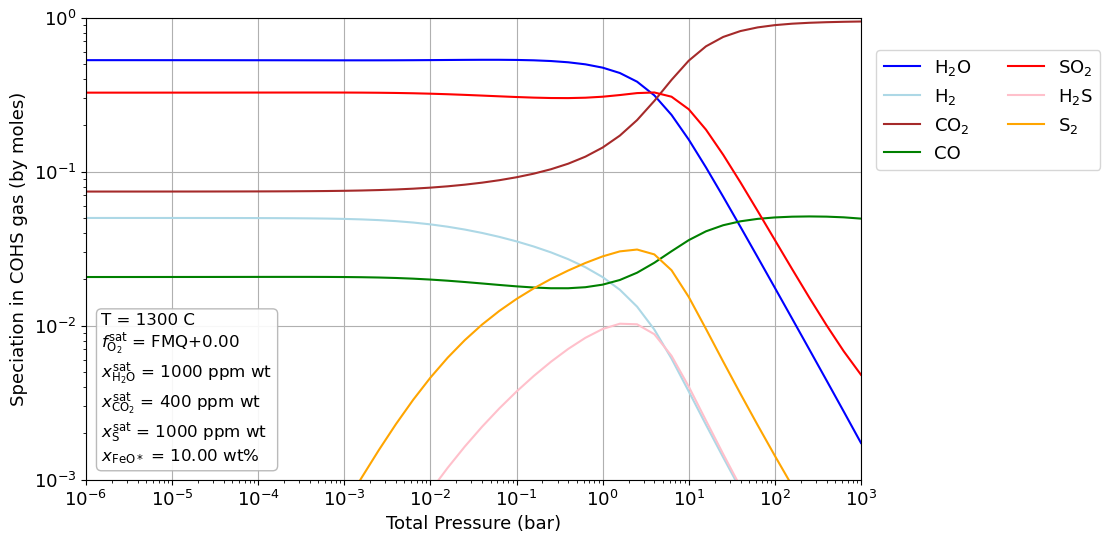

In [176]:
### Outgassing calcuation

T = 1300 + 273.15  # C + 273.15 = K
mH2O_sat = 1000 * 1e-6 # magma H2O content at saturation in ppm wt -- actually just H content
mCO2_sat = 400 * 1e-6 # magma CO2 content at saturation in ppm wt -- actually just C content
mS_sat = 1000 * 1e-6 # magma S content at saturation in ppm wt -- just S content
FMQ_sat =  0 # fO2 at saturation relative to FMQ buffer
alphaG_sat = 1e-8 # Assume amount of gas in melt at saturation by mol (0.3-0.7 wt% from IM 2012; 0.01 wt% for GS 2009)
FeO_star_wt = 10 * 1e-2 # Total FeO in melt

outgassing_precalc = calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False)
plot_speciation(outgassing_precalc)

P_target (bar): 1.00e-02
P_at_target (bar): 1.00e-02
P_surf (dyn/cm^2): 1.00e+04
mu_gas_atm_input (g/mol): 34.525
Input mixing ratios:
   H2O: 0.530
    H2: 0.045
   CO2: 0.079
    CO: 0.020
   CH4: 0.000
    S2: 0.005
   SO2: 0.321
   H2S: 0.001
Output profile levels: 51
T range (K): 384.93 - 751.77
Returned species: ['1CH2', 'C', 'C2', 'C2H', 'C2H2', 'C2H2OH', 'C2H3', 'C2H3OH', 'C2H4', 'C2H4OH', 'C2H5', 'C2H6', 'C3H4', 'C3H6', 'C4H', 'C4H2', 'C4H3', 'C4H4', 'CH', 'CH2', 'CH2CHO', 'CH2CO', 'CH3', 'CH3CHO', 'CH3CO', 'CH3O', 'CH3O2', 'CH3OH', 'CH4', 'CO', 'CO2', 'CS', 'CS2', 'H', 'H2', 'H2CO', 'H2COH', 'H2O', 'H2O2', 'H2S', 'H2SO4', 'HCCO', 'HCO', 'HCS', 'HO2', 'HS', 'HS4', 'HSO', 'HSO3', 'O', 'O1D', 'O2', 'O3', 'OCS', 'OH', 'S', 'S2', 'S3', 'S4', 'S8', 'SO', 'SO2', 'SO3']
Saved plot to: figures/atm_from_outgassing_P_1.00e-02_bar.pdf


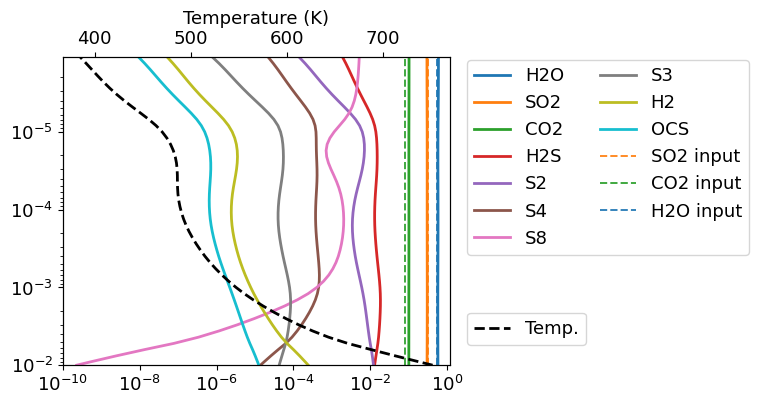

In [177]:
P_target_bar = 1e-2  # choose the outgassing pressure level to feed into the atmosphere model
pressure_match_fraction = 0.01

P_grid = np.asarray(outgassing_precalc['P'], dtype=float)
finite_p_idx = np.where(np.isfinite(P_grid))[0]
if finite_p_idx.size == 0:
    raise ValueError('outgassing_precalc does not contain any finite pressure levels.')

idx_local = int(np.argmin(np.abs(P_grid[finite_p_idx] - P_target_bar)))
idx = int(finite_p_idx[idx_local])
P_at_target = float(P_grid[idx])

if P_at_target <= 0.0:
    raise ValueError(f'Selected pressure must be positive, got {P_at_target}.')
if abs(P_at_target - P_target_bar) > pressure_match_fraction * P_target_bar:
    raise ValueError(
        f'Closest outgassing pressure ({P_at_target:.3e} bar) is not within '
        f'{pressure_match_fraction:.0%} of P_target_bar={P_target_bar:.3e} bar.'
    )

# Surface pressure conversion: bar -> dyn/cm^2
P_surf = P_at_target * 1.0e6

species_names = ['H2O', 'H2', 'CO2', 'CO', 'CH4', 'S2', 'SO2', 'H2S']
mix = {}
for sp in species_names:
    partial_pressure = float(outgassing_precalc[sp][idx])
    if np.isfinite(partial_pressure) and partial_pressure > 0.0:
        mix[sp] = partial_pressure / P_at_target

if not mix:
    raise ValueError('No positive finite atmospheric input species were found at the selected pressure level.')

mu_gas = sum(mix[sp] * mu_dict[sp] for sp in mix)
plot_filename = (
    f'figures/atm_from_outgassing_P_{P_at_target:.2e}_bar.pdf'
    .replace('+', '')
)

# Run climate model
P_atm, T_atm, mix_profile = run(P_surf, mix, verbose=False)

print(f'P_target (bar): {P_target_bar:.2e}')
print(f'P_at_target (bar): {P_at_target:.2e}')
print(f'P_surf (dyn/cm^2): {P_surf:.2e}')
print(f'mu_gas_atm_input (g/mol): {mu_gas:.3f}')
print('Input mixing ratios:')
for sp, val in mix.items():
    print(f'  {sp:>4s}: {val:.3f}')

print(f'Output profile levels: {len(P_atm)}')
print(f'T range (K): {np.nanmin(T_atm):.2f} - {np.nanmax(T_atm):.2f}')
print('Returned species:', sorted(mix_profile.keys()))

# Plot and save
plot(P_atm, T_atm, mix_profile, ylim=(P_atm[0] / 1e6, P_atm[-1] / 1e6), filename=plot_filename, input_mix=mix)
print(f'Saved plot to: {plot_filename}')


In [178]:
### Run atmosphere model at 3 pressure levels and store results

import os

P_targets_bar = [1e-5, 1e-2, 1.0]
species_gas = ['H2O', 'H2', 'CO2', 'CO', 'CH4', 'S2', 'SO2', 'H2S']

atm_results = {}
for P_tgt in P_targets_bar:
    P_grid_og = np.asarray(outgassing_precalc['P'], dtype=float)
    finite_idx = np.where(np.isfinite(P_grid_og))[0]
    idx = int(finite_idx[np.argmin(np.abs(P_grid_og[finite_idx] - P_tgt))])
    P_at = float(P_grid_og[idx])

    mix_in = {
        sp: float(outgassing_precalc[sp][idx]) / P_at
        for sp in species_gas
        if np.isfinite(outgassing_precalc[sp][idx]) and outgassing_precalc[sp][idx] > 0.0
    }

    try:
        P_atm, T_atm, mix_prof = run(P_at * 1e6, mix_in, verbose=False)
        atm_results[P_tgt] = (P_at, mix_in, P_atm, T_atm, mix_prof)
        print(f"P_tot = {P_at:.1e} bar: done")
    except Exception as e:
        print(f"Atmosphere model failed for P_tot={P_tgt:.1e} bar: {e}")
        atm_results[P_tgt] = None


P_tot = 1.0e-05 bar: done
P_tot = 1.0e-02 bar: done
P_tot = 1.0e+00 bar: done


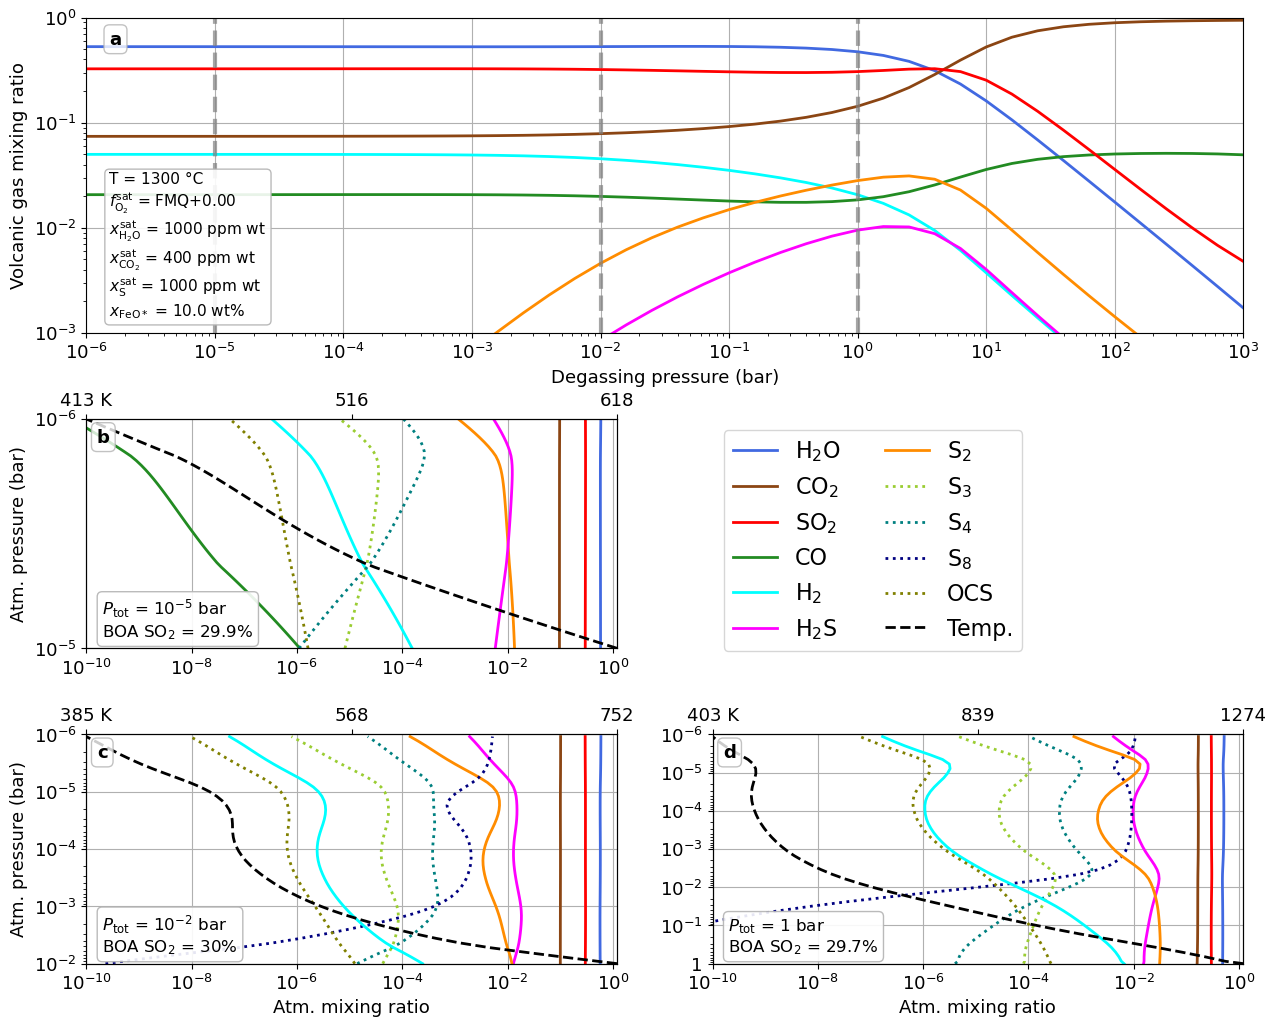

In [179]:
def plot_multi_panel(outgassing_results, atm_results, P_targets_bar,
                     spec_params=None, legend_order=None,
                     filename='figures/morb_multi_panel.pdf'):
    """
    Four-row, two-column multi-panel figure:
      Rows 0-1, cols 0-1 : volcanic COHS speciation (spans 2 rows, full width)
      Row 2,    col 0    : first atmospheric profile
      Row 2,    col 1    : shared legend
      Row 3,    col 0    : second atmospheric profile
      Row 3,    col 1    : third atmospheric profile
    """
    import os, math
    from matplotlib.ticker import FuncFormatter, NullLocator

    plt.rcParams.update({'font.size': 13})

    # Fixed color map — distinct colors for all species
    sp_clr = {
        'H2O': 'royalblue',
        'H2':  'cyan',
        'CO2': 'saddlebrown',
        'CO':  'forestgreen',
        'SO2': 'red',
        'H2S': 'magenta',
        'S2':  'darkorange',
        'CH4': 'purple',
        # Atmosphere-only sulfur/carbonyl species — dotted lines
        'S3':  'yellowgreen',
        'S4':  'teal',
        'S8':  'navy',
        'OCS': 'olive',
    }
    # Species that appear only in the atmosphere — plotted with dotted lines
    atm_only_sp = {'S3', 'S4', 'S8', 'OCS'}

    # Display labels with proper LaTeX subscripts
    sp_label = {
        'H2O': r'H$_2$O',
        'H2':  r'H$_2$',
        'CO2': r'CO$_2$',
        'CO':  r'CO',
        'SO2': r'SO$_2$',
        'H2S': r'H$_2$S',
        'S2':  r'S$_2$',
        'CH4': r'CH$_4$',
        'S3':  r'S$_3$',
        'S4':  r'S$_4$',
        'S8':  r'S$_8$',
        'OCS': r'OCS',
        'Temp.': 'Temp.',
    }

    def _fmt_ptot(p):
        """Format a pressure value as '$10^{x}$ bar', '1 bar', or plain decimal."""
        if p <= 0:
            return f'{p} bar'
        exp = int(round(math.log10(p)))
        mantissa = p / 10**exp
        if abs(mantissa - 1.0) < 0.05:
            if exp == 0:
                return '1 bar'
            return rf'$10^{{{exp}}}$ bar'
        else:
            # Not a clean power of 10 — show as plain decimal
            return f'{p:.4g} bar'

    def _pressure_tick_fmt(val, pos):
        """Format pressure tick as '10^x' or '1'."""
        if val <= 0:
            return ''
        exp = int(round(math.log10(val)))
        if exp == 0:
            return '1'
        return f'$10^{{{exp}}}$'

    # Helper: formatter that appends ' K' only to the leftmost visible tick
    def _kelvin_fmt(ax_ref):
        def _fmt(val, pos):
            try:
                lo, hi = ax_ref.get_xlim()
                span = abs(hi - lo)
                visible = sorted(t for t in ax_ref.get_xticks()
                                 if lo - 0.01*span <= t <= hi + 0.01*span)
                if visible and abs(val - visible[0]) < 0.001 * max(1.0, span):
                    return f'{int(round(val))} K'
            except Exception:
                pass
            return f'{int(round(val))}'
        return FuncFormatter(_fmt)

    fig = plt.figure(figsize=(13, 11))
    gs = fig.add_gridspec(
        4, 2,
        height_ratios=[1, 1, 2, 2],
        hspace=0.50, wspace=0.18,
        left=0.08, right=0.97, top=0.93, bottom=0.07,
    )
    ax_spec   = fig.add_subplot(gs[0:2, :])  # rows 0-1: speciation, full width
    ax_atm1   = fig.add_subplot(gs[2, 0])    # row 2, col 0: first atm
    ax_legend = fig.add_subplot(gs[2, 1])    # row 2, col 1: shared legend
    ax_atm2   = fig.add_subplot(gs[3, 0])    # row 3, col 0
    ax_atm3   = fig.add_subplot(gs[3, 1])    # row 3, col 1
    ax_legend.axis('off')
    ax_atms = [ax_atm1, ax_atm2, ax_atm3]

    _lbl_bbox = dict(facecolor='white', edgecolor='0.7', alpha=0.8, boxstyle='round,pad=0.3')
    _atm_panel_lbls = dict(zip(ax_atms, ['b', 'c', 'd']))

    # ── Panel label for speciation panel (no twiny, draw now) ────────────
    ax_spec.text(0.02, 0.96, 'a', transform=ax_spec.transAxes,
                 ha='left', va='top', fontsize=13, fontweight='bold', bbox=_lbl_bbox)

    # ── Speciation panel ──────────────────────────────────────────────────
    P_grid = outgassing_results['P']
    for sp, color in [
        ('H2O', sp_clr['H2O']), ('H2', sp_clr['H2']), ('CO2', sp_clr['CO2']),
        ('CO',  sp_clr['CO']),  ('SO2', sp_clr['SO2']), ('H2S', sp_clr['H2S']),
        ('S2',  sp_clr['S2']),
    ]:
        arr = outgassing_results.get(sp, np.full_like(P_grid, np.nan))
        ax_spec.loglog(P_grid, np.divide(arr, P_grid), color=color, lw=2)

    for P_tgt in P_targets_bar:
        ax_spec.axvline(P_tgt, color='gray', lw=3, ls='--', alpha=0.7)

    if spec_params is not None:
        param_lines = []
        if 'T_C'     in spec_params:
            param_lines.append(f'T = {spec_params["T_C"]:.0f} \u00b0C')
        if 'FMQ'     in spec_params:
            param_lines.append(rf'$f_{{\mathrm{{O_2}}}}^{{\mathrm{{sat}}}}$ = FMQ{spec_params["FMQ"]:+.2f}')
        if 'H2O_ppm' in spec_params:
            param_lines.append(rf'$x_{{\mathrm{{H_2O}}}}^{{\mathrm{{sat}}}}$ = {spec_params["H2O_ppm"]:.0f} ppm wt')
        if 'CO2_ppm' in spec_params:
            param_lines.append(rf'$x_{{\mathrm{{CO_2}}}}^{{\mathrm{{sat}}}}$ = {spec_params["CO2_ppm"]:.0f} ppm wt')
        if 'S_ppm'   in spec_params:
            param_lines.append(rf'$x_{{\mathrm{{S}}}}^{{\mathrm{{sat}}}}$ = {spec_params["S_ppm"]:.0f} ppm wt')
        if 'FeO_wt'  in spec_params:
            param_lines.append(rf'$x_{{\mathrm{{FeO*}}}}$ = {spec_params["FeO_wt"]:.1f} wt%')
        ax_spec.text(
            0.02, 0.04, '\n'.join(param_lines),
            transform=ax_spec.transAxes, ha='left', va='bottom', fontsize=11,
            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9, boxstyle='round,pad=0.3'),
        )

    ax_spec.set_xlim(1e-6, 1e3)
    ax_spec.set_ylim(1e-3, 1)
    ax_spec.set_xlabel('Degassing pressure (bar)')
    ax_spec.set_ylabel('Volcanic gas mixing ratio')
    ax_spec.grid(True)

    # ── Atmospheric profile panels ────────────────────────────────────────
    legend_handles     = []
    legend_labels_seen = []  # stored as raw keys for deduplication/ordering

    p_fmt = FuncFormatter(_pressure_tick_fmt)

    T_lower_bound = {0: None, 1: None, 2: None}  # None = use data min

    for j, (ax, P_tgt) in enumerate(zip(ax_atms, P_targets_bar)):
        res = atm_results.get(P_tgt)
        if res is None:
            ax.text(0.5, 0.5, 'Model failed', ha='center', va='center',
                    transform=ax.transAxes)
            continue

        P_at, mix_in, P_atm, T_atm, mix_prof = res
        p_toa  = P_atm[-1] / 1e6   # bar (TOA, smaller)

        # Species lines — top 10 by abundance at ~1 mbar
        P_ref   = 1e3  # dyn/cm^2
        ind_ref = np.argmin(np.abs(P_atm - P_ref))
        top_sp  = sorted(mix_prof, key=lambda s: mix_prof[s][ind_ref], reverse=True)[:10]

        for sp in top_sp:
            c  = sp_clr.get(sp)
            ls = ':' if sp in atm_only_sp else '-'
            line, = ax.plot(mix_prof[sp], P_atm / 1e6, lw=2, ls=ls,
                            **({'color': c} if c is not None else {}))
            if sp not in legend_labels_seen:
                legend_handles.append(line)
                legend_labels_seen.append(sp)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1e-10, 1.2)
        ax.set_ylim(P_tgt, p_toa)  # lower bound = target pressure exactly
        ax.grid(True)

        # Y-axis ticks and labels
        if j == 0:
            # Top-left panel: boundary ticks only — suppress all minor ticks too
            ax.set_yticks([P_tgt, p_toa])
            ax.yaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_major_formatter(p_fmt)
            ax.set_ylabel('Atm. pressure (bar)')
        else:
            lo_e = int(math.floor(math.log10(p_toa)))
            hi_e = int(math.ceil(math.log10(P_tgt)))
            tick_vals = [10.0**e for e in range(lo_e, hi_e + 1)]
            ax.set_yticks(tick_vals)
            ax.yaxis.set_major_formatter(p_fmt)
            if j == 1:
                ax.set_ylabel('Atm. pressure (bar)')

        # X-axis label on bottom row panels
        if j in (1, 2):
            ax.set_xlabel('Atm. mixing ratio')

        # P_tot + BOA SO2 label: bottom left
        so2_arr = mix_prof.get('SO2')
        if so2_arr is not None and np.isfinite(so2_arr[0]):
            so2_pct = so2_arr[0] * 100
            so2_str = f'BOA SO$_2$ = {so2_pct:.3g}%'
        else:
            so2_str = r'BOA SO$_2$ = N/A'
        label_text = f'$P_{{\\rm tot}}$ = {_fmt_ptot(P_at)}\n{so2_str}'
        ax.text(
            0.03, 0.03, label_text,
            transform=ax.transAxes, ha='left', va='bottom', fontsize=12,
            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9, boxstyle='round,pad=0.3'),
        )

        # Temperature twin x-axis: ticks at min, mid, and max T
        T_max = T_atm.max()
        T_min = T_lower_bound[j] if T_lower_bound[j] is not None else T_atm.min()
        T_mid = (T_min + T_max) / 2.0
        ax_T = ax.twiny()
        t_handle, = ax_T.plot(T_atm, P_atm / 1e6, c='k', lw=2, ls='--')
        ax_T.set_xlim(T_min, T_max)
        ax_T.set_xticks([T_min, T_mid, T_max])
        ax_T.xaxis.set_major_formatter(_kelvin_fmt(ax_T))
        if j == 0:
            legend_handles.append(t_handle)
            legend_labels_seen.append('Temp.')

        # Draw panel label on ax_T (topmost axes) so it appears above the temp line
        ax_T.text(0.02, 0.96, _atm_panel_lbls[ax], transform=ax_T.transAxes,
                  ha='left', va='top', fontsize=13, fontweight='bold', bbox=_lbl_bbox)

    # ── Apply legend order ────────────────────────────────────────────────
    if legend_order is not None:
        order_map = {lbl: i for i, lbl in enumerate(legend_labels_seen)}
        ordered   = [(legend_handles[order_map[lbl]], lbl)
                     for lbl in legend_order if lbl in order_map]
        remaining = [(h, lbl) for h, lbl in zip(legend_handles, legend_labels_seen)
                     if lbl not in legend_order]
        pairs = ordered + remaining
        if pairs:
            legend_handles, legend_labels_seen = zip(*pairs)

    # Convert raw keys to display labels with proper subscripts
    display_labels = [sp_label.get(lbl, lbl) for lbl in legend_labels_seen]

    # ── Shared legend ─────────────────────────────────────────────────────
    ax_legend.legend(
        handles=legend_handles,
        labels=display_labels,
        loc='upper left',
        ncol=2,
        fontsize=16,
        frameon=True,
    )

    os.makedirs('figures', exist_ok=True)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# ── Call ─────────────────────────────────────────────────────────────────

# Edit this list to reorder items in the shared legend.
# Any species/labels not listed are appended in collection order at the end.
legend_order = [
    'H2O', 'CO2', 'SO2', 'CO', 'H2', 'H2S','S2','S3','S4', 'S8', 'OCS', 'Temp.'
]

spec_params = {
    'T_C':     T - 273.15,
    'FMQ':     FMQ_sat,
    'H2O_ppm': mH2O_sat * 1e6,
    'CO2_ppm': mCO2_sat * 1e6,
    'S_ppm':   mS_sat * 1e6,
    'FeO_wt':  FeO_star_wt * 100,
}
plot_multi_panel(outgassing_precalc, atm_results, P_targets_bar,
                 spec_params=spec_params, legend_order=legend_order)
